### Initialization and data preprocessing

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from rail_rl_env import RailNet, gurobi_minlp, gurobi_qp, qp_feasible, action_dict, qp_feasible, gurobi_qp

import matplotlib.pylab as plt

data_sets = np.load('training_sets.npy', allow_pickle=True).item()
d_pre = data_sets['d_pre']
rho_whole = data_sets['rho_whole']
un = data_sets['un']
ul = data_sets['ul']
uy = data_sets['uy']
ua = data_sets['ua']
ud = data_sets['ud']
utau = data_sets['utau']
ur = data_sets['ur']
depot = data_sets['depot']

r_max = data_sets['r_max']
r_min = data_sets['r_min']
differ = data_sets['differ']
Cmax = data_sets['Cmax']
sigma = data_sets['sigma']
same = data_sets['same']
num_station = data_sets['num_station']
num_train = data_sets['num_train']
E_regular = data_sets['E_regular']

epsilon = 10 ** (-10)
Mt = 1000000
mt = -1000000
t_constant = 60
h_min = 120
tau_min = 30
l_min = 1
l_max = 4
eta = 10**(-3)

g = 3

control_trains = 8
N = control_trains
N_control = N-2
Env = RailNet(N)

#network parameters
num_actions = int(list(action_dict)[-1])+1 #index starts at 0
input_size=314

In [2]:
# dataset information for normalization and stardadization

num_passengers_mean = un.transpose((1,0,2)).reshape(28,-1).mean(axis=1)
num_passengers_max = un.transpose((1,0,2)).reshape(28,-1).max(axis=1)
num_passengers_min = un.transpose((1,0,2)).reshape(28,-1).min(axis=1)
num_passengers_std = un.transpose((1,0,2)).reshape(28,-1).std(axis=1)

rho_mean = rho_whole.transpose((1,0,2)).reshape(28,-1).mean(axis=1)
rho_max = rho_whole.transpose((1,0,2)).reshape(28,-1).max(axis=1)
rho_min = rho_whole.transpose((1,0,2)).reshape(28,-1).min(axis=1)
rho_std = rho_whole.transpose((1,0,2)).reshape(28,-1).std(axis=1)

rho_min = np.tile(rho_min, N+1)
rho_max = np.tile(rho_max, N+1)

depot_mean = depot.transpose((1,0,2)).reshape(14,-1).mean(axis=1)[[0,-1]]
depot_max = depot.transpose((1,0,2)).reshape(14,-1).max(axis=1)[[0,-1]]
depot_min = depot.transpose((1,0,2)).reshape(14,-1).min(axis=1)[[0,-1]]
depot_std = depot.transpose((1,0,2)).reshape(14,-1).std(axis=1)[[0,-1]]

train_composition_mean = ul.transpose((1,0,2)).reshape(28,-1).mean()
train_composition_max = ul.transpose((1,0,2)).reshape(28,-1).max()
train_composition_min = ul.transpose((1,0,2)).reshape(28,-1).min()
train_composition_std = ul.transpose((1,0,2)).reshape(28,-1).std()

In [3]:
def norm_state(state, state_min, state_max):
    # simple state normalization when the constraints are of the form state_min <= state <= state_max
        
    state_span = state_max - state_min
    
    state_norm = (state-state_min)/(state_span+1e-8)
    
    state_norm = (state_norm-0.5)*2
    
    return state_norm

def preprocess_state(state_n, state_rho, state_depot, state_l):
    
    #concatenates and normalizes the state
    
    num_passengers = state_n
    rho_flat = state_rho.flatten()
    depot_reduced = state_depot[[0,-1]] # removes 0 padding

    #keeps the current train composition and also the past compositions at platforms 0 and 14
    train_composition_reduced = np.zeros(32,)
    train_composition_reduced[0:2] = np.flip(state_l[1:,0])
    train_composition_reduced[2:16] = state_l[0,:14] # only current train composition
    train_composition_reduced[16:18] = np.flip(state_l[1:,14])
    train_composition_reduced[18:] = state_l[0,14:]

    num_passengers_norm = norm_state(num_passengers, num_passengers_min, num_passengers_max)
    rho_flat_norm = norm_state(rho_flat, rho_min, rho_max)
    depot_reduced_norm = norm_state(depot_reduced, depot_min, depot_max)
    train_composition_reduced_norm = norm_state(train_composition_reduced, train_composition_min, train_composition_max)

    state_learning = np.concatenate((num_passengers_norm, rho_flat_norm, depot_reduced_norm, train_composition_reduced_norm))
    
    return state_learning

In [4]:
def compress_minlp_info(state_n, state_rho, state_depot, state_l, delta_minlp):
    
    minlp_info_compressed = np.concatenate((state_n, state_rho.flatten(), state_depot, state_l.flatten(), delta_minlp.flatten()))
    
    return minlp_info_compressed

def decompress_minlp_info(minlp_info_compressed):
    
    state_n = minlp_info_compressed[0:28]
    
    state_rho = minlp_info_compressed[28:28+28*9].reshape(9,28)
    
    state_depot = minlp_info_compressed[28+28*9:28+28*9+14]
    
    state_l = minlp_info_compressed[28+28*9+14:28+28*9+14+28*3].reshape(3,28)
    
    delta_minlp = minlp_info_compressed[28+28*9+14+28*3:-1].reshape(6,8)
    
    obj_val = minlp_info_compressed[-1]
    
    return state_n, state_rho, state_depot, state_l, delta_minlp, obj_val

In [5]:
# solution_minlp = []
# N_datapoints=50

# minlp_info_compressed = np.zeros((N_datapoints, 426))

# for i in range(N_datapoints):

#     Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)

#     state_n = Env.state_n
#     state_rho = Env.state_rho
#     state_depot = Env.state_depot
#     state_l = Env.state_l

#     a_minlp, d_minlp, r_minlp, l_minlp, y_minlp, delta_minlp, mdl_minlp = gurobi_minlp(control_trains, Env.d_pre_cut, Env.state_rho,
#                             Env.state_a, Env.state_d, Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot,
#                             num_station, differ, sigma, same, t_constant, h_min, l_min, l_max, r_min, r_max, tau_min,
#                             E_regular, Cmax, eta)
    
#     # solution_minlp.append([state_n, state_rho, state_depot, state_l, delta_minlp, mdl_minlp.ObjVal])
    
#     minlp_info_compressed[i,:] = compress_minlp_info(state_n, state_rho, state_depot, state_l, delta_minlp)

In [6]:
# np.save('data_minlp//data_minlp_N%.2d.npy' %N, minlp_info_compressed, allow_pickle=True)

In [8]:
# minlp_info_compressed = np.load('data_minlp//data_minlp_N%.2d.npy' %N, allow_pickle=True)
minlp_info_compressed = np.load('data_minlp//data_minlp_N08_0425.npy', allow_pickle=True)
N_datapoints = minlp_info_compressed.shape[0]

In [9]:
inv_action_dict = {tuple(v[0]): int(k) for k, v in action_dict.items()}

def build_list_action(delta: np.array) -> list:
    list_action = [inv_action_dict[tuple(delta[0])]]
    for i in range(1, control_trains-2):
        list_action.append(inv_action_dict[tuple(delta[i])])
        
    return list_action

stacked_states = np.zeros((N_datapoints,N_control,input_size))
stacked_labels = np.zeros((N_datapoints,N_control,num_actions))
stacked_obj_val = np.zeros((N_datapoints,))

stacked_list_actions = np.zeros((N_datapoints, N_control))

for j in range(N_datapoints):
    
    #input preprocessing
    
    state_n, state_rho, state_depot, state_l, delta_minlp, obj_val = decompress_minlp_info(minlp_info_compressed[j,:])
    
    # state_n = solution_minlp[j][0]
    # state_rho = solution_minlp[j][1]
    # state_depot = solution_minlp[j][2]
    # state_l = solution_minlp[j][3]
    
    stacked_states[j,0,:] = preprocess_state(state_n, state_rho, state_depot, state_l)
    stacked_states[j,1:,:] = np.zeros((N_control-1, input_size))
    
    #label preprocessing

    # delta_minlp = solution_minlp[j][4] # takes the delta_minlp from the optimal solution

    idx_0 = j*np.ones(N_control, dtype=np.int32)
    idx_1 = np.arange(N_control)
    idx_2 = build_list_action(np.round(delta_minlp,2))
    idx_list = list(zip(idx_0, idx_1, idx_2))

    for k in range(N_control):
        stacked_labels[idx_list[k]] = 1
        
    stacked_obj_val[j] = obj_val
    
    stacked_list_actions[j] = idx_2 
        
def split_train_validation(stacked_states, stacked_labels, split_position=0.8):
    N_datapoints = stacked_states.shape[0]
    
    stacked_states_train = stacked_states[:int(np.ceil(N_datapoints*split_position))]
    stacked_labels_train = stacked_labels[:int(np.ceil(N_datapoints*split_position))]
    
    stacked_states_val = stacked_states[int(np.ceil(N_datapoints*split_position)):]
    stacked_labels_val = stacked_labels[int(np.ceil(N_datapoints*split_position)):]
    
    return stacked_states_train, stacked_labels_train, stacked_states_val, stacked_labels_val

In [10]:
stacked_states_train, stacked_labels_train, stacked_states_val, stacked_labels_val = split_train_validation(stacked_states, stacked_labels, split_position=0.8)

<BarContainer object of 80 artists>

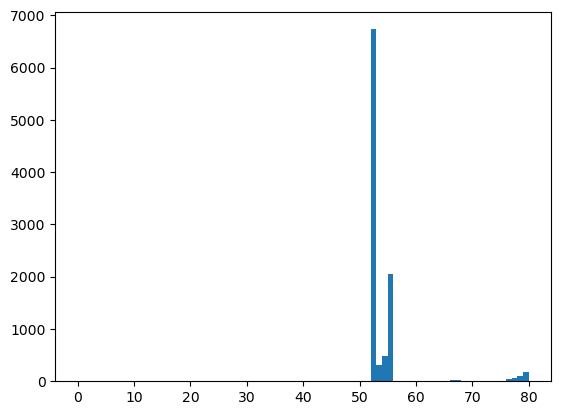

In [17]:
#frequency of optimal actions
plt.hist(stacked_list_actions[:,0], np.arange(81))[2]

### Training

In [18]:
class Network(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, lr, n_actions, batch_first=True):
        super(Network, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lr = lr
        self.n_actions = n_actions
        self.batch_first = batch_first        
        
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=batch_first)
        self.dense = nn.Linear(hidden_size, n_actions)
        
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss = nn.MSELoss()
        
    def forward(self, input, h0, c0):
        
        # input = torch.randn(batch_size, seq_len, input_size)
        # h0 = torch.randn(num_layers, batch_size, hidden_size)
        # c0 = torch.randn(num_layers, batch_size, hidden_size)

        output, (hn, cn) = self.lstm(input, (h0, c0))
        
        output = self.dense(output)
        # output = nn.ReLU()(output)
        output = nn.Softmax(dim=2)(output)

        return output

In [19]:
hidden_size=512
num_layers=1
lr=1e-3

network = Network(input_size, hidden_size, num_layers, lr, num_actions)

batch_size=32
seq_len=N_control
# input = torch.randn(batch_size, seq_len, input_size)

In [20]:
# training
N_iter = 20000

loss_train = np.zeros((N_iter,1))
loss_val = []

h0 = torch.zeros(num_layers, batch_size, hidden_size)
c0 = torch.zeros(num_layers, batch_size, hidden_size)

for i in range(N_iter):

    batch = np.random.choice(stacked_states_train.shape[0], batch_size, replace=False)

    state_batch_train = torch.tensor(stacked_states_train[batch], dtype=torch.float32)
    labels_batch_train = torch.tensor(stacked_labels_train[batch], dtype=torch.float32)

    net_eval = network(state_batch_train, h0, c0)

    loss = network.loss(net_eval, labels_batch_train)
    
    loss_train[i] = loss.detach().numpy()

    network.zero_grad()        
    loss.backward()
    network.optimizer.step()
    
    if i % 100 == 0:
        with torch.no_grad():
            batch = np.random.choice(stacked_states_val.shape[0], batch_size, replace=False)
            state_batch_val = torch.tensor(stacked_states_val[batch], dtype=torch.float32)
            labels_batch_val = torch.tensor(stacked_labels_val[batch], dtype=torch.float32)
            net_eval = network(state_batch_val, h0, c0)
            loss_val.append(network.loss(net_eval, labels_batch_val).detach().numpy())

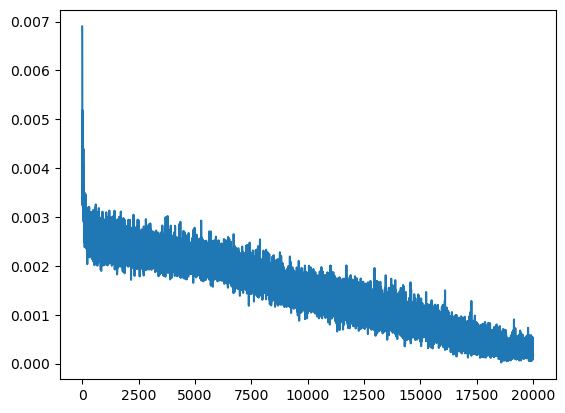

In [21]:
# loss_val = np.array(loss_val)

plt.plot(loss_train)
# plt.plot(loss_val)
plt.show()

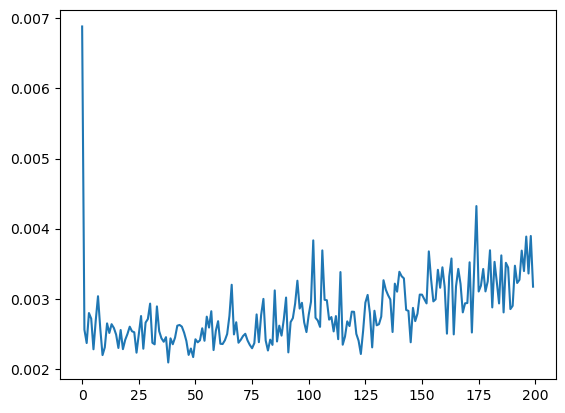

In [22]:
plt.plot(loss_val)
plt.show()

In [23]:
# torch.save(network.state_dict(), 'best_weights//microgrid_lstm_supervised_%d_N%d_opt1'%(hidden_size, N))
# network.load_state_dict(torch.load('trained_weights//microgrid_lstm_supervised_128_option1'))

#### Testing the trained neural network

In [24]:
def build_delta_vector(list_action: list) -> np.array:
        # from list of actions builds a np.array with the stacked deltas for each time step of the prediction horizon
        delta = action_dict[str(int(list_action[0]))]
        for i in range(1, N_control):
            delta = np.concatenate((delta, action_dict[str(int(list_action[i]))]))

        return delta

In [25]:
batch_size = 1

h0 = torch.zeros(num_layers, batch_size, hidden_size)
c0 = torch.zeros(num_layers, batch_size, hidden_size)

batch = np.random.choice(stacked_states_train.shape[0], batch_size, replace=False)

state_batch_train = torch.tensor(stacked_states_train[batch], dtype=torch.float32)
labels_batch_train = torch.tensor(stacked_labels_train[batch], dtype=torch.float32)

output_net = network(state_batch_train, h0, c0)
list_action = torch.max(output_net, dim=2)[1].squeeze().numpy()
delta_SL = build_delta_vector(list_action)

loss = network.loss(output_net, labels_batch_train)
loss

tensor(6.6363e-05, grad_fn=<MseLossBackward0>)

In [26]:
# Loads the trained Neural Network

# network = Network(input_size, hidden_size, num_layers, lr, num_actions)
# network.load_state_dict(torch.load('trained_weights//microgrid_lstm_supervised_128_option1'))k

In [29]:
seed=42
torch.manual_seed(seed)
np.random.seed(seed)

n_threads = 8

Env = RailNet(N)

network.eval()
batch_size=1
h0 = torch.zeros(num_layers, batch_size, hidden_size)
c0 = torch.zeros(num_layers, batch_size, hidden_size)

N_test = 100 # number of test simulations

tmp_state = np.zeros((N_control, input_size))

cntr_infeas_minlp = 0
cntr_infeas_nlp = 0

list_cost = []
list_cost_minlp = []
list_time = []

list_opt_gap = []

for i in range(N_test):
    
    Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
        
    state_n = Env.state_n
    state_rho = Env.state_rho
    state_depot = Env.state_depot
    state_l = Env.state_l

    tmp_state[0, :] = preprocess_state(state_n, state_rho, state_depot, state_l)
    tmp_state[1:,:] = np.zeros((N_control-1, input_size))
    state_learning = torch.tensor(tmp_state, dtype=torch.float32).unsqueeze(0)    
    output_net = network(state_learning, h0, c0)
    list_action = torch.max(output_net, dim=2)[1].squeeze().numpy()
    delta_SL = build_delta_vector(list_action)

    _,_,_,_,_,mdl = gurobi_qp(Env.control_trains,Env.d_pre_cut,Env.state_rho, Env.state_a, Env.state_d,
                    Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot, delta_SL,
                    num_station,differ,sigma,same,t_constant,h_min,l_min,l_max,r_min,
                    r_max,tau_min,E_regular,Cmax,eta)
    
    _,_,_,_,_,delta_minlp, mdl_minlp = gurobi_minlp(Env.control_trains,Env.d_pre_cut,Env.state_rho, Env.state_a, Env.state_d,
                Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot,
                num_station,differ,sigma,same,t_constant,h_min,l_min,l_max,r_min,
                r_max,tau_min,E_regular,Cmax,eta, n_threads)
    
    list_action_minlp = build_list_action(np.round(delta_minlp,2))

    feasible_nlp = qp_feasible(mdl)
    if feasible_nlp == False:   cntr_infeas_nlp+=1
    
    feasible_minlp = qp_feasible(mdl)
    if feasible_minlp == False:   cntr_infeas_minlp+=1

    if feasible_nlp and feasible_minlp == True:
        list_cost.append(mdl.ObjVal)
        list_cost_minlp.append(mdl_minlp.ObjVal)
        
        opt_gap = (mdl.ObjVal - mdl_minlp.ObjVal)/(mdl_minlp.ObjVal)*100
        list_opt_gap.append(opt_gap)
        
        print(mdl.ObjVal, mdl_minlp.ObjVal, list_action, list_action_minlp, opt_gap)       
    
    # print(feasible, mdl.ObjVal, mdl_minlp.ObjVal, list_action, list_action_minlp, opt_gap)

17216.63369111008 17216.63369111005 [52 52 52  4  4  4] [52, 52, 52, 52, 52, 4] 1.690448375617221e-13
16396.79732401445 16396.7973247657 [52 52 52 52  4  4] [52, 52, 52, 52, 52, 4] -4.581686805918899e-09
16285.89120928588 16285.891208447087 [52  4  4  4  4  4] [52, 52, 52, 52, 52, 4] 5.150434881947671e-09
19384.896182694865 19275.470204915575 [54 54 52 54 52  4] [53, 54, 52, 52, 54, 4] 0.567695504265234
15891.537367592315 15891.537366823643 [52 52 52  4  4  4] [52, 4, 4, 4, 4, 4] 4.836990672368505e-09
17626.09421530666 17626.094215156856 [52 52  4  4  4  4] [52, 4, 4, 4, 4, 4] 8.499029307899874e-10
16632.91756140694 16632.917561407114 [52  4  4  4  4  4] [52, 52, 4, 52, 52, 4] -1.049863814305044e-12
18494.920384644996 18494.92038552652 [52 52 52 52  4  4] [52, 4, 4, 4, 4, 4] -4.7662940112737584e-09
17180.698415070045 17180.698415070074 [52 52  4  4  4  4] [52, 52, 4, 4, 4, 4] -1.6939841299586073e-13
15961.58398333804 15961.583983337998 [52  4 52 52 52  4] [52, 52, 4, 4, 4, 4] 2.6210905

In [30]:
np.mean(list_opt_gap), len(list_opt_gap), np.max(list_opt_gap)

(0.1793605654579785, 94, 3.0366232181243418)

In [31]:
cntr_infeas_minlp, cntr_infeas_nlp

(6, 6)